<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/NLP_and_Deep_Learning_on_SPAM_Data_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib seaborn nltk spacy sklearn wordcloud plotly gensim transformers torch
!python -m spacy download en_core_web_sm

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud

In [ ]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
df = pd.read_csv('/content/spam (1).csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df = df[['v1','v2']]
df.columns=['label','text']

In [ ]:
df['label'] = df['label'].map({'ham':0,'spam':1})
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


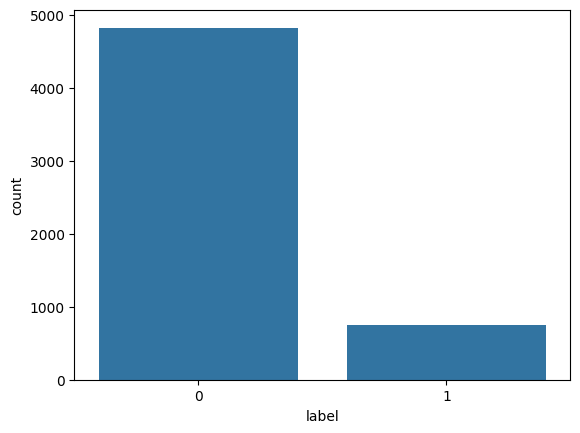

In [ ]:
sns.countplot(x='label',data=df)
plt.show()

In [ ]:
df['length'] = df['text'].apply(len)

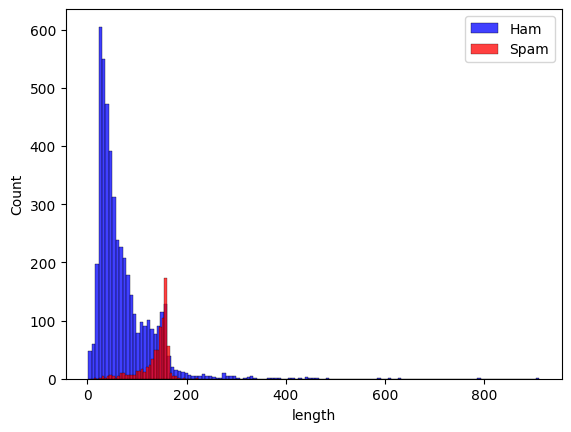

In [ ]:
sns.histplot(df[df['label']==0]['length'],color='blue')
sns.histplot(df[df['label']==1]['length'],color='red')
plt.legend(['Ham','Spam'])
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

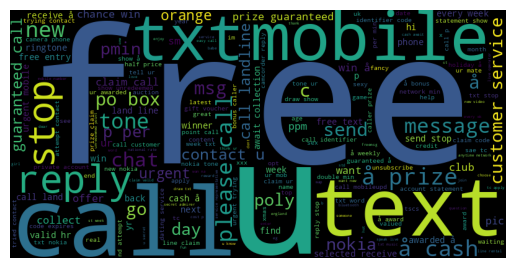

In [ ]:
spam_words = " ".join(df[df['label']==1]['clean_text'])

wc = WordCloud(width=800, height=400).generate(spam_words)

plt.imshow(wc)
plt.axis("off")
plt.show()


In [ ]:
import plotly.express as px

df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

fig = px.scatter_3d(
    df,
    x='length',
    y='word_count',
    z='label'
)

fig.show()


In [ ]:
bow = CountVectorizer()
X = bow.fit_transform(df['clean_text'])
y = df['label']

In [ ]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['clean_text'])


In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
nb = MultinomialNB()
nb.fit(X_train,y_train)

pred = nb.predict(X_test)

print(accuracy_score(y_test,pred))

0.9596412556053812


In [ ]:
lr = LogisticRegression()
lr.fit(X_train,y_train)

pred = lr.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       977
           1       0.99      0.55      0.71       138

    accuracy                           0.94      1115
   macro avg       0.96      0.77      0.84      1115
weighted avg       0.95      0.94      0.94      1115



In [ ]:
!pip install gensim


from gensim.models import Word2Vec

sentences = [text.split() for text in df['clean_text']]

w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

w2v.wv['free']


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.4 MB/s eta 0:00:00


array([-0.29272422,  0.6641323 ,  0.08567975, -0.08225736, -0.06733295,
       -1.0100915 ,  0.18460086,  1.0344943 , -0.27520153, -0.39982602,
       -0.22686256, -0.7286912 , -0.05724183,  0.30961373,  0.05445442,
       -0.4173519 ,  0.23870178, -0.63590574,  0.03336839, -1.0075448 ,
        0.4470644 ,  0.22379869,  0.3168905 , -0.23683615, -0.1848845 ,
        0.10582529, -0.36000007, -0.42593357, -0.7125306 ,  0.0840916 ,
        0.5892418 ,  0.17611574,  0.10172698, -0.44877782, -0.42944556,
        0.77199084,  0.18527785, -0.46621162, -0.44912314, -0.8735021 ,
        0.00244495, -0.42540658, -0.27238715,  0.11188413,  0.47451523,
       -0.3214142 , -0.4583944 , -0.14206026,  0.26993576,  0.3494246 ,
        0.16842037, -0.401011  , -0.07020942, -0.0811862 , -0.32707372,
        0.24950658,  0.18276283,  0.01734004, -0.40818533,  0.22994658,
        0.19182181,  0.24693668, -0.14250186, -0.1340057 , -0.68963933,
        0.44217315,  0.26586568,  0.33813897, -0.56964856,  0.72

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_text'])

seq = tokenizer.texts_to_sequences(df['clean_text'])
padded = pad_sequences(seq)

vocab_size = len(tokenizer.word_index) + 1

X_train, X_test, y_train, y_test = train_test_split(padded, y, test_size=0.2)

model = Sequential()
model.add(Embedding(vocab_size, 64))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)


Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.8910 - loss: 0.3205
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9875 - loss: 0.0468
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9949 - loss: 0.0189
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9992 - loss: 0.0047
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9989 - loss: 0.0034


In [ ]:
from transformers import pipeline
classifier = pipeline('sentiment-analysis')
classifier('I love this movie')

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9998766183853149}]

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification

import nltk

nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')   # just in case

nltk.pos_tag(word_tokenize("NLP is amazing"))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[('NLP', 'NNP'), ('is', 'VBZ'), ('amazing', 'VBG')]

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("Elon Musk founded SpaceX")

for ent in doc.ents:
    print(ent.text, ent.label_)


Elon Musk founded PERSON


<Axes: >

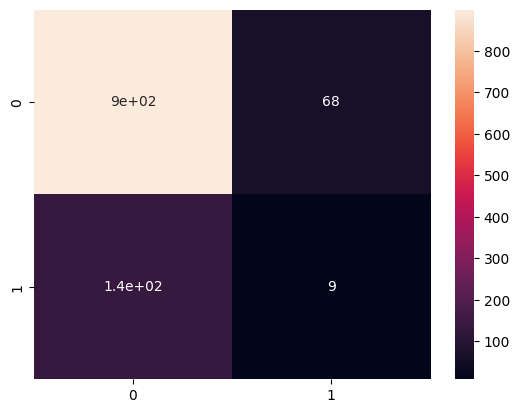

In [ ]:
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test,pred), annot=True)

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5)
lda.fit(X)


LatentDirichletAllocation(n_components=5)